# Evaluación comparativa: Qwen × Retrieval — retrieval en inferencia

Este notebook **no entrena ningún modelo**.

Los modelos fine-tuned se entrenan previamente mediante:

- `scripts/experiments/train_qwen_fallback.py`
- `scripts/experiments/train_qwen_context.py`

El objetivo es comparar:

1. Qwen base + ContextRetriever
2. Qwen base + FallbackRetriever
3. Qwen fine-tuned + ContextRetriever
4. Qwen fine-tuned + FallbackRetriever

## Importante

Las cachés `fallback_retrieval_cache.json` y `context_retrieval_cache.json`
generadas durante el entrenamiento **NO se utilizan para el test**.

Para evaluar, este notebook ejecuta el retrieval sobre el conjunto de test.
En `FallbackRetriever`, esto permite que el motor web se utilice realmente
durante la evaluación cuando el contexto local no sea suficiente.

La recuperación de cada estrategia se ejecuta una sola vez sobre el test y
se guarda como caché de **inferencia**. Después se reutiliza exactamente el
mismo contexto para Qwen base y Qwen fine-tuned, de modo que la comparación
entre modelos no quede contaminada por cambios entre búsquedas web.

In [11]:
# 1. Configuración

import gc
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "data" / "questions_train.json").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError(
            "No se encontró data/questions_train.json."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocess.preprocess import prepare_dataset
from src.evaluate import evaluate_predictions
from src.retrieval.context_retriever import ContextRetriever
from src.retrieval.fallback_retriever import FallbackRetriever


MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

MAX_LENGTH = 384
MAX_NEW_TOKENS = 32
SEED = 42

INDEX_PATH = PROJECT_ROOT / "models" / "context_embeddings.pt"
MODELS_DIR = PROJECT_ROOT / "models" / "comparison_2x2"
RESULTS_DIR = PROJECT_ROOT / "results" / "comparison_2x2"

# Qwen se ejecuta en GPU si está disponible.
MODEL_DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Retrieval en CPU para no competir con Qwen por VRAM.
RETRIEVER_DEVICE = torch.device("cpu")

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Dispositivo Qwen: {MODEL_DEVICE}")
print(f"Dispositivo retrieval: {RETRIEVER_DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"VRAM total: "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )

Proyecto: c:\Users\chech\Practica_PLN_II
Dispositivo Qwen: cuda
Dispositivo retrieval: cpu
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM total: 15.93 GB


In [12]:
# 2. Dataset y split FIJO

dataset = prepare_dataset(
    str(PROJECT_ROOT / "data" / "questions_train.json"),
    str(PROJECT_ROOT / "data" / "contexts.json"),
)

train_data, test_data = train_test_split(
    dataset,
    test_size=0.2,
    random_state=SEED,
)

print(f"Total: {len(dataset)}")
print(f"Train: {len(train_data)}")
print(f"Test: {len(test_data)}")

Total: 350
Train: 280
Test: 70


In [13]:
# 3. Prompt

with open(
    PROJECT_ROOT / "prompts" / "primer.md",
    encoding="utf-8",
) as f:
    SYSTEM_PROMPT = f.read().strip()

print("Prompt cargado.")

Prompt cargado.


In [14]:
# 4. Limpieza de memoria

def cleanup_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass


def gpu_memory(label):
    if not torch.cuda.is_available():
        return

    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    peak = torch.cuda.max_memory_allocated() / 1024**3

    print(
        f"[{label}] "
        f"VRAM allocated={allocated:.2f} GB | "
        f"reserved={reserved:.2f} GB | "
        f"peak={peak:.2f} GB"
    )


def reset_gpu_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()


cleanup_memory()

In [15]:
# 5. Retrieval REAL durante la evaluación

INFERENCE_CONTEXT_CACHE = (
    RESULTS_DIR / "inference_context_test.json"
)
INFERENCE_FALLBACK_CACHE = (
    RESULTS_DIR / "inference_fallback_test.json"
)


def retrieve_test_live(samples, retriever, retriever_name):
    results = []

    print(
        f"Ejecutando {retriever_name} sobre "
        f"{len(samples)} preguntas de TEST..."
    )

    for i, sample in enumerate(samples, start=1):
        retrieved = retriever.retrieve(sample["question"])

        if retrieved is None:
            retrieved = {}

        results.append({
            **sample,
            "context": retrieved.get("context", "") or "",
            "context_id": retrieved.get("context_id", "none"),
            "score": float(retrieved.get("score", 0.0)),
            "source": retrieved.get("source", "none"),
            "retrieval": retrieved.get("retrieval", "none"),
        })

        if i % 10 == 0 or i == len(samples):
            print(
                f"{retriever_name}: {i}/{len(samples)}"
            )

    return results


def load_or_run_inference_retrieval(
    retriever_name,
    samples,
):
    if retriever_name == "ContextRetriever":
        cache_path = INFERENCE_CONTEXT_CACHE
        retriever_factory = lambda: ContextRetriever(
            str(INDEX_PATH),
            device=RETRIEVER_DEVICE,
        )
    elif retriever_name == "FallbackRetriever":
        cache_path = INFERENCE_FALLBACK_CACHE
        retriever_factory = lambda: FallbackRetriever(
            str(INDEX_PATH),
            device=RETRIEVER_DEVICE,
            threshold=0.60,
            margin=0.03,
        )
    else:
        raise ValueError(
            f"Retriever desconocido: {retriever_name}"
        )

    # Esta caché es EXCLUSIVAMENTE de retrieval de INFERENCIA.
    # No utiliza las cachés generadas durante el entrenamiento.
    if cache_path.exists():
        print(
            f"Usando caché de INFERENCIA existente: "
            f"{cache_path.name}"
        )
        with open(cache_path, encoding="utf-8") as f:
            return json.load(f)

    retriever = retriever_factory()

    try:
        retrieved_test = retrieve_test_live(
            samples,
            retriever,
            retriever_name,
        )
    finally:
        del retriever
        cleanup_memory()

    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    with open(
        cache_path,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            retrieved_test,
            f,
            ensure_ascii=False,
            indent=2,
        )

    print(
        f"Guardada caché de INFERENCIA: "
        f"{cache_path}"
    )

    return retrieved_test

In [16]:
# 6. Ejecutar retrieval de TEST antes de cargar Qwen

# IMPORTANTE:
# Aquí se produce la recuperación de inferencia.
#
# FallbackRetriever puede llegar a WebRetriever/DuckDuckGo
# para las preguntas que no tengan suficiente contexto local.

context_test = load_or_run_inference_retrieval(
    "ContextRetriever",
    test_data,
)

cleanup_memory()

fallback_test = load_or_run_inference_retrieval(
    "FallbackRetriever",
    test_data,
)

cleanup_memory()

print()
print(f"ContextRetriever test: {len(context_test)}")
print(f"FallbackRetriever test: {len(fallback_test)}")

web_hits = sum(
    1
    for item in fallback_test
    if item.get("source") == "web"
    or item.get("retrieval") == "web"
)

print(
    f"FallbackRetriever con fuente web: "
    f"{web_hits}/{len(fallback_test)}"
)

Usando caché de INFERENCIA existente: inference_context_test.json
Usando caché de INFERENCIA existente: inference_fallback_test.json

ContextRetriever test: 70
FallbackRetriever test: 70
FallbackRetriever con fuente web: 23/70


In [17]:
# 7. Tokenizer y funciones de generación

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def make_messages(item):
    context = item["context"] or "No context is available."

    return [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": (
                f"Context:\n{context}\n\n"
                f"Question: {item['question']}"
            ),
        },
    ]


def load_base_model():
    if MODEL_DEVICE.type == "cuda":
        dtype = torch.bfloat16
    else:
        dtype = torch.float32

    reset_gpu_peak()

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=dtype,
        low_cpu_mem_usage=True,
    )

    model = model.to(MODEL_DEVICE)
    model.eval()

    gpu_memory("modelo base cargado")

    return model


def load_finetuned_model(adapter_name):
    base_model = load_base_model()

    adapter_path = MODELS_DIR / adapter_name

    if not adapter_path.exists():
        raise FileNotFoundError(
            f"No existe el adapter: {adapter_path}"
        )

    model = PeftModel.from_pretrained(
        base_model,
        adapter_path,
    )

    model.eval()

    gpu_memory(f"adapter {adapter_name} cargado")

    return model


def generate_answer(model, item):
    prompt = tokenizer.apply_chat_template(
        make_messages(item),
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )

    inputs = {
        key: value.to(MODEL_DEVICE)
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            use_cache=True,
        )

    generated_ids = outputs[
        :,
        inputs["input_ids"].shape[1]:,
    ]

    answer = tokenizer.batch_decode(
        generated_ids,
        skip_special_tokens=True,
    )[0].strip()

    del inputs
    del outputs
    del generated_ids

    return answer

In [18]:
# 8. Evaluación de una condición

def evaluate_condition(
    model,
    samples,
    model_name,
    retriever_name,
):
    results = []

    for i, item in enumerate(samples, start=1):
        prediction = generate_answer(
            model,
            item,
        )

        results.append({
            "question": item["question"],
            "prediction": prediction,
            "reference": item["answer"],
            "has_answer": item["has_answer"],
            "retrieved_context_id": item["context_id"],
            "retrieval_score": item["score"],
            "retrieval_source": item["source"],
            "retrieval_type": item["retrieval"],
            "model": model_name,
            "retriever": retriever_name,
        })

        if i % 10 == 0 or i == len(samples):
            print(
                f"{model_name} + {retriever_name}: "
                f"{i}/{len(samples)}"
            )

    return results


def run_condition(
    model_loader,
    samples,
    model_name,
    retriever_name,
):
    model = None

    cleanup_memory()
    reset_gpu_peak()

    try:
        print()
        print("=" * 70)
        print(f"{model_name} + {retriever_name}")
        print("=" * 70)

        model = model_loader()

        results = evaluate_condition(
            model,
            samples,
            model_name,
            retriever_name,
        )

        gpu_memory(
            f"fin {model_name} + {retriever_name}"
        )

        return results

    finally:
        if model is not None:
            del model

        cleanup_memory()

        gpu_memory(
            f"después de liberar "
            f"{model_name} + {retriever_name}"
        )

## 9. Ejecutar las cuatro condiciones

El retrieval ya se ha realizado en el paso 6.

Por tanto:

- Base + Context usa `context_test`.
- Base + Fallback usa `fallback_test`.
- Fine-tuned + Context usa **el mismo** `context_test`.
- Fine-tuned + Fallback usa **el mismo** `fallback_test`.

Esto significa que Base y Fine-tuned reciben exactamente la misma evidencia recuperada para cada pregunta.

In [19]:
# 9.1 Qwen Base + ContextRetriever

results_base_context = run_condition(
    load_base_model,
    context_test,
    "Qwen Base",
    "ContextRetriever",
)


Qwen Base + ContextRetriever


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

[modelo base cargado] VRAM allocated=28.46 GB | reserved=28.69 GB | peak=28.46 GB
Qwen Base + ContextRetriever: 10/70
Qwen Base + ContextRetriever: 20/70
Qwen Base + ContextRetriever: 30/70
Qwen Base + ContextRetriever: 40/70
Qwen Base + ContextRetriever: 50/70
Qwen Base + ContextRetriever: 60/70
Qwen Base + ContextRetriever: 70/70
[fin Qwen Base + ContextRetriever] VRAM allocated=28.46 GB | reserved=28.80 GB | peak=28.55 GB
[después de liberar Qwen Base + ContextRetriever] VRAM allocated=14.24 GB | reserved=14.36 GB | peak=28.55 GB


In [20]:
# 9.2 Qwen Base + FallbackRetriever

results_base_fallback = run_condition(
    load_base_model,
    fallback_test,
    "Qwen Base",
    "FallbackRetriever",
)


Qwen Base + FallbackRetriever


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

[modelo base cargado] VRAM allocated=28.46 GB | reserved=28.69 GB | peak=28.46 GB
Qwen Base + FallbackRetriever: 10/70
Qwen Base + FallbackRetriever: 20/70
Qwen Base + FallbackRetriever: 30/70
Qwen Base + FallbackRetriever: 40/70
Qwen Base + FallbackRetriever: 50/70
Qwen Base + FallbackRetriever: 60/70
Qwen Base + FallbackRetriever: 70/70
[fin Qwen Base + FallbackRetriever] VRAM allocated=28.46 GB | reserved=28.80 GB | peak=28.55 GB
[después de liberar Qwen Base + FallbackRetriever] VRAM allocated=14.24 GB | reserved=14.36 GB | peak=28.55 GB


In [21]:
# 9.3 Qwen Fine-tuned + ContextRetriever

results_ft_context = run_condition(
    lambda: load_finetuned_model(
        "qwen_lora_context"
    ),
    context_test,
    "Qwen Fine-tuned",
    "ContextRetriever",
)


Qwen Fine-tuned + ContextRetriever


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

[modelo base cargado] VRAM allocated=28.46 GB | reserved=28.69 GB | peak=28.46 GB
[adapter qwen_lora_context cargado] VRAM allocated=28.48 GB | reserved=28.72 GB | peak=28.50 GB
Qwen Fine-tuned + ContextRetriever: 10/70
Qwen Fine-tuned + ContextRetriever: 20/70
Qwen Fine-tuned + ContextRetriever: 30/70
Qwen Fine-tuned + ContextRetriever: 40/70
Qwen Fine-tuned + ContextRetriever: 50/70
Qwen Fine-tuned + ContextRetriever: 60/70
Qwen Fine-tuned + ContextRetriever: 70/70
[fin Qwen Fine-tuned + ContextRetriever] VRAM allocated=28.48 GB | reserved=28.82 GB | peak=28.57 GB
[después de liberar Qwen Fine-tuned + ContextRetriever] VRAM allocated=14.24 GB | reserved=14.36 GB | peak=28.57 GB


In [22]:
# 9.4 Qwen Fine-tuned + FallbackRetriever

results_ft_fallback = run_condition(
    lambda: load_finetuned_model(
        "qwen_lora_fallback"
    ),
    fallback_test,
    "Qwen Fine-tuned",
    "FallbackRetriever",
)


Qwen Fine-tuned + FallbackRetriever


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

[modelo base cargado] VRAM allocated=28.46 GB | reserved=28.69 GB | peak=28.46 GB
[adapter qwen_lora_fallback cargado] VRAM allocated=28.48 GB | reserved=28.72 GB | peak=28.50 GB
Qwen Fine-tuned + FallbackRetriever: 10/70
Qwen Fine-tuned + FallbackRetriever: 20/70
Qwen Fine-tuned + FallbackRetriever: 30/70
Qwen Fine-tuned + FallbackRetriever: 40/70
Qwen Fine-tuned + FallbackRetriever: 50/70
Qwen Fine-tuned + FallbackRetriever: 60/70
Qwen Fine-tuned + FallbackRetriever: 70/70
[fin Qwen Fine-tuned + FallbackRetriever] VRAM allocated=28.48 GB | reserved=28.82 GB | peak=28.57 GB
[después de liberar Qwen Fine-tuned + FallbackRetriever] VRAM allocated=14.24 GB | reserved=14.36 GB | peak=28.57 GB


In [23]:
# 10. Métricas

all_results = (
    results_base_context
    + results_base_fallback
    + results_ft_context
    + results_ft_fallback
)


def metrics_by_answer_status(results):
    answerable = [
        x for x in results
        if x["has_answer"]
    ]

    unanswerable = [
        x for x in results
        if not x["has_answer"]
    ]

    return {
        "overall": evaluate_predictions(results),
        "answerable": evaluate_predictions(answerable),
        "unanswerable": evaluate_predictions(unanswerable),
    }


conditions = {
    "Qwen Base + Context": metrics_by_answer_status(
        results_base_context
    ),
    "Qwen Base + Fallback": metrics_by_answer_status(
        results_base_fallback
    ),
    "Qwen Fine-tuned + Context": metrics_by_answer_status(
        results_ft_context
    ),
    "Qwen Fine-tuned + Fallback": metrics_by_answer_status(
        results_ft_fallback
    ),
}

rows = []

for condition, metrics in conditions.items():
    for subset, values in metrics.items():
        rows.append({
            "condition": condition,
            "subset": subset,
            "EM": values["exact_match"],
            "F1": values["f1_score"],
            "N": values["total_evaluated"],
        })

comparison_df = pd.DataFrame(rows)

display(
    comparison_df[
        comparison_df["subset"] == "overall"
    ].sort_values("F1", ascending=False)
)

display(comparison_df)

,condition,subset,EM,F1,N
6,Qwen Fine-tuned + Context,overall,71.43,75.35,70
9,Qwen Fine-tuned + Fallback,overall,68.57,73.96,70
3,Qwen Base + Fallback,overall,18.57,36.87,70
0,Qwen Base + Context,overall,15.71,30.85,70


,condition,subset,EM,F1,N
0,Qwen Base + Context,overall,15.71,30.85,70
1,Qwen Base + Context,answerable,20.37,40.00,54
2,Qwen Base + Context,unanswerable,0.00,0.00,16
3,Qwen Base + Fallback,overall,18.57,36.87,70
4,Qwen Base + Fallback,answerable,24.07,47.80,54
5,Qwen Base + Fallback,unanswerable,0.00,0.00,16
6,Qwen Fine-tuned + Context,overall,71.43,75.35,70
7,Qwen Fine-tuned + Context,answerable,68.52,73.61,54
8,Qwen Fine-tuned + Context,unanswerable,81.25,81.25,16
9,Qwen Fine-tuned + Fallback,overall,68.57,73.96,70


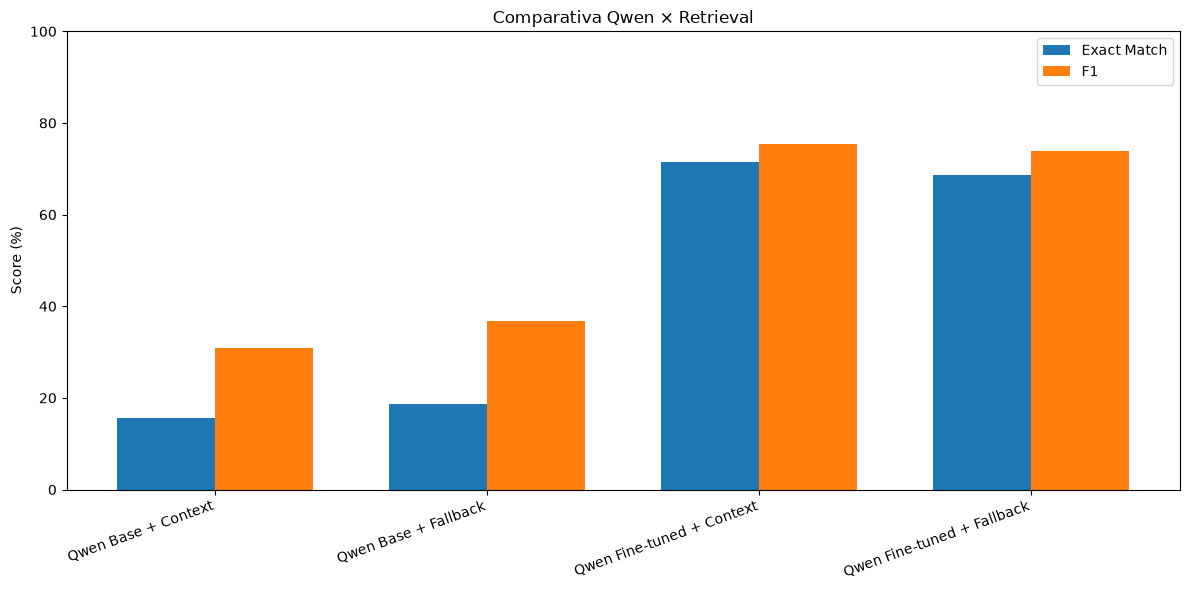

In [24]:
# 11. Gráfica

overall = comparison_df[
    comparison_df["subset"] == "overall"
].copy()

x = np.arange(len(overall))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width / 2,
    overall["EM"],
    width,
    label="Exact Match",
)

ax.bar(
    x + width / 2,
    overall["F1"],
    width,
    label="F1",
)

ax.set_xticks(x)
ax.set_xticklabels(
    overall["condition"],
    rotation=20,
    ha="right",
)

ax.set_ylabel("Score (%)")
ax.set_title("Comparativa Qwen × Retrieval")
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

In [25]:
# 12. Efecto de cada variable

def score(condition, metric="F1"):
    return float(
        overall.loc[
            overall["condition"] == condition,
            metric,
        ].iloc[0]
    )


effect_df = pd.DataFrame([
    {
        "comparacion": "Fine-tuning + Fallback",
        "sin_FT": score("Qwen Base + Fallback"),
        "con_FT": score("Qwen Fine-tuned + Fallback"),
        "delta": (
            score("Qwen Fine-tuned + Fallback")
            - score("Qwen Base + Fallback")
        ),
    },
    {
        "comparacion": "Fine-tuning + Context",
        "sin_FT": score("Qwen Base + Context"),
        "con_FT": score("Qwen Fine-tuned + Context"),
        "delta": (
            score("Qwen Fine-tuned + Context")
            - score("Qwen Base + Context")
        ),
    },
    {
        "comparacion": "Fallback en Qwen Base",
        "Context": score("Qwen Base + Context"),
        "Fallback": score("Qwen Base + Fallback"),
        "delta": (
            score("Qwen Base + Fallback")
            - score("Qwen Base + Context")
        ),
    },
    {
        "comparacion": "Fallback en Qwen Fine-tuned",
        "Context": score("Qwen Fine-tuned + Context"),
        "Fallback": score("Qwen Fine-tuned + Fallback"),
        "delta": (
            score("Qwen Fine-tuned + Fallback")
            - score("Qwen Fine-tuned + Context")
        ),
    },
])

display(effect_df)

,comparacion,sin_FT,con_FT,delta,Context,Fallback
0,Fine-tuning + Fallback,36.87,73.96,37.09,NaN,NaN
1,Fine-tuning + Context,30.85,75.35,44.50,NaN,NaN
2,Fallback en Qwen Base,NaN,NaN,6.02,30.85,36.87
3,Fallback en Qwen Fine-tuned,NaN,NaN,-1.39,75.35,73.96


In [26]:
# 13. Análisis del retrieval usado en inferencia

fallback_web = sum(
    1
    for item in fallback_test
    if item.get("source") == "web"
    or item.get("retrieval") == "web"
)

fallback_local = sum(
    1
    for item in fallback_test
    if item.get("source") != "web"
    and item.get("retrieval") != "web"
)

retrieval_summary = pd.DataFrame([
    {
        "retriever": "ContextRetriever",
        "test_questions": len(context_test),
        "web_searches": 0,
    },
    {
        "retriever": "FallbackRetriever",
        "test_questions": len(fallback_test),
        "web_searches": fallback_web,
    },
])

display(retrieval_summary)

print(
    f"FallbackRetriever: {fallback_local} resultados "
    f"sin fuente web y {fallback_web} con fuente web."
)

,retriever,test_questions,web_searches
0,ContextRetriever,70,0
1,FallbackRetriever,70,23


FallbackRetriever: 47 resultados sin fuente web y 23 con fuente web.


In [27]:
# 14. Guardar resultados

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

with open(
    RESULTS_DIR / "comparison_metrics.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        conditions,
        f,
        ensure_ascii=False,
        indent=2,
    )

with open(
    RESULTS_DIR / "comparison_predictions.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        all_results,
        f,
        ensure_ascii=False,
        indent=2,
    )

overall.to_csv(
    RESULTS_DIR / "comparison_overall.csv",
    index=False,
)

effect_df.to_csv(
    RESULTS_DIR / "comparison_effects.csv",
    index=False,
)

print("Resultados guardados en:")
print(RESULTS_DIR)

Resultados guardados en:
c:\Users\chech\Practica_PLN_II\results\comparison_2x2
